In [1]:
from IPython.display import HTML

In [2]:
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

In [3]:
Ld = 2
L1d = 1
L2d = 1
th1d = 0
w1d = 0
th2d = 0
w2d = 0
m1d = 1
m2d = 1
kd = 1
g = 9.8

dt = 0.05
to = 0
tf = 20
tDefault = np.arange(to, tf, dt)


In [4]:
def derivs(t,Y, L1,L2,m1,m2,k): #Y = [thetha1, omega1, theta2, omega2] omega1 = thetha1dot

    #Y  = [th1,thd1, th2,thd2]
    
    dydx = np.zeros_like(Y) #começo vetor dydx = [0,0,0,0]
    dydx[0] = Y[1]

    thd1 = Y[1]
    thd2 = Y[3]
    th1 = Y[0]
    th2 = Y[2]
    
    dydx[1] = -((m1*g+k*L1-L1*m1*thd1**2)*np.sin(th1)-k*L2*np.sin(th2))/(L1*m1*np.cos(th1))

    dydx[2] = Y[3]

    dydx[3] = -((m2*g+k*L2-L2*m2*thd2**2)*np.sin(th2)-k*L1*np.sin(th1))/(L2*m2*np.cos(th2))

    return dydx


def GetPosition(th1 = th1d,w1 = w1d ,th2 = th2d ,w2 = w2d, t = tDefault,L1 = L1d,L2 = L2d,m1 = m1d,m2 = m2d,k= kd, L = Ld):
    # initial Y
    Yo = np.radians([th1, w1, th2, w2])

    # integrate your ODE using scipy.integrate.
    #y = odeint(derivs, Yo, t, args = (L1,L2,m1,m2,k))

    to = tDefault[0]
    tf = tDefault[-1]
    y = solve_ivp(derivs, (to, tf),Yo,vectorized=True, args = (L1,L2,m1,m2,k), t_eval = tDefault)

    theta1,omega1, theta2,omega2 = y.y[0],y.y[1],y.y[2],y.y[3]
    
    x1 = L1*np.sin(theta1)
    y1 = -L1*np.cos(theta1)


    x2 = L+L2*np.sin(theta2)
    y2 = -L2*np.cos(theta2)
    
    
    return x1, x2, y1, y2, y

In [5]:
def update(i, x1,y1,x2,y2, L, t, par1,par2,bar1,bar2,spring,time_text):
    try:
        par1.set_data(x1[i],y1[i])
        par2.set_data(x2[i],y2[i])
        bar1.set_data([0,x1[i]],[0,y1[i]])
        bar2.set_data([L,x2[i]],[0,y2[i]])
        spring.set_data([x1[i],x2[i]],[y1[i],y2[i]] )
        s = "t = {time}".format(time = np.round(t[i],2))
        time_text.set_text(s) # atualiza o time text
    except:
        print(i, "errado")
    #time_text.set_text(time_template % (t))
    return par1, par2, bar1, bar2, spring

In [6]:
#test
#g = 9.8
#L = 2
#L1,L2,m1,m2,k = 1,1,1,1,0
#Yo = 15,0,15,0
#y = solve_ivp(derivs, (to, tf),Yo,vectorized=True, args = (L1,L2,m1,m2,k), t_eval = tDefault)
#theta1,omega1, theta2,omega2 = y.y[0],y.y[1],y.y[2],y.y[3]

#x1 = L1*np.sin(theta1)
#y1 = -L1*np.cos(theta1)

#x2 = L+L2*np.sin(theta2)
#y2 = -L2*np.cos(theta2)
    
#t = y.t

In [11]:
def Total(th1 = th1d,w1 = w1d ,th2 = th2d ,w2 = w2d, t = tDefault,L1 = L1d,L2 = L2d,m1 = m1d,m2 = m2d,k= kd, L = Ld):
    
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.set_xlim(((-L1-L2)/2),L + (L1+L2)/2)
    ax.set_ylim((-L1-L2,2))


    time_text = ax.text(-0.4, 0.35, 'test')
    par1, = plt.plot([],[], marker='o', color='black') ## Create empty 2D Line object
    par2, = plt.plot([],[], marker='o', color='black') #Esto es un objeto de plot y tiene la propiedad .set_data que actualiza el array de x y y, cada update
    bar1, = plt.plot([],[], color='r') #Esto es un objeto de plot y tiene la propiedad .set_data que actualiza el array de x y y, cada update
    bar2, = plt.plot([],[], color='b') #Esto es un objeto de plot y tiene la propiedad .set_data que actualiza el array de x y y, cada update
    spring, = plt.plot([],[], marker= "*",color='purple') #Esto es un objeto de plot y tiene la propiedad .set_data que actualiza el array de x y y, cada update
    plt.close()
    
    
    x1, x2, y1, y2, y = GetPosition(th1,w1 ,th2 ,w2, t,L1,L2,m1,m2,k, L)
    theta1,omega1, theta2,omega2 = y.y[0],y.y[1],y.y[2],y.y[3]
    
    #theta1,omega1, theta2,omega2 = y[:,0],y[:,1],y[:,2],y[:,3]
    ani = animation.FuncAnimation(fig, update, frames=range(len(y.t)), interval=25, fargs = (x1,y1,x2,y2, L, t, par1,par2,bar1,bar2,spring, time_text))
    
    HTML(ani.to_html5_video())

    return ani, y
    
    

In [42]:
ani, y  = Total(th1 = 15,th2 = 0, k = 15)
HTML(ani.to_html5_video())

In [13]:
from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets


In [22]:
slow = interactive(Total, {'manual': True}, th1 = widgets.FloatSlider(min=-180, max=180, step=5, value = 25) ,w1 = widgets.FloatSlider(min=0, max=10, step=1) ,th2 = widgets.FloatSlider(min=-180, max=180, step=5, value = 25) ,w2 = widgets.FloatSlider(min=0, max=10, step=1), t = fixed(tDefault),L1 = widgets.FloatSlider(min=0, max=20, step=1, value = 1),L2 = widgets.FloatSlider(min=0, max=20, step=1, value = 1),m1 = widgets.FloatSlider(min=0, max=10, step=1, value = 1),m2 = widgets.FloatSlider(min=0, max=10, step=1, value = 1),k= widgets.FloatSlider(min=0.001, max=5, step=0.25, value = 1), L = widgets.FloatSlider(min=0, max=20, step=1, value = 2))
display(slow)

interactive(children=(FloatSlider(value=25.0, description='th1', max=180.0, min=-180.0, step=5.0), FloatSlider…

In [30]:
%%time
HTML(slow.result[0].to_html5_video())


CPU times: user 174 µs, sys: 2 µs, total: 176 µs
Wall time: 167 µs


In [ ]:
tdeetrans em funçao de l

In [156]:
%%time
ani, y  = Total(th1 = 15,th2 = 0,L = 2, k = 20)
HTML(ani.to_html5_video())



CPU times: user 24.4 s, sys: 372 ms, total: 24.7 s
Wall time: 25.1 s


In [48]:
%%time
ani, y3  = Total(th1 = 15, th2 = 0,L = 3, k = 20)
HTML(ani.to_html5_video())


CPU times: user 22.2 s, sys: 220 ms, total: 22.5 s
Wall time: 22.9 s


In [150]:
%%time
ani, y4  = Total(th1 = 15,th2 = 0,L = 4, k = 20)
HTML(ani.to_html5_video())


CPU times: user 21.9 s, sys: 276 ms, total: 22.2 s
Wall time: 22.5 s


In [151]:
%%time
ani, y5  = Total(th1 = 15,th2 = 0,L = 5, k = 20)
HTML(ani.to_html5_video())


CPU times: user 23.6 s, sys: 275 ms, total: 23.9 s
Wall time: 24.4 s


In [152]:
%%time
ani, y7  = Total(th1 = 15,th2 = 0,L = 7, k = 20)
HTML(ani.to_html5_video())

CPU times: user 22.2 s, sys: 267 ms, total: 22.5 s
Wall time: 22.8 s


In [111]:
def totalenergy(y,L, k = 20 , m1=1,m2=1, L1=1,L2=1 ):

    theta1,omega1, theta2,omega2 = y.y[0],y.y[1],y.y[2],y.y[3]

    x1 = L1*np.sin(theta1)
    y1 = -L1*np.cos(theta1)

    x2 = L+L2*np.sin(theta2)
    y2 = -L2*np.cos(theta2)

    t = y.t
    
    x1dot = L1*np.cos(theta1)*omega1
    x2dot = L2*np.cos(theta2)*omega2

    y1dot = L1*np.sin(theta1)*omega1
    y2dot = L2*np.sin(theta2)*omega2
    
    K1 = 0.5*m1*x1dot**2 
    K2 = 0.5*m2*x2dot**2

    uspring = 0.5*k*(x2-x1)**2
    up1 = m1*g*y1
    up2 = m2*g*y2
    
    ki = K1+K2
    u = up1+up2
    totalE = K1+K2+up1+up2+uspring
    Ep1 = up1+K1
    Ep2 = up2+K2
    return totalE, t, ki,u, Ep1, Ep2, uspringm 

In [114]:
def plotenergy(y,L, k = 20 , m1=1,m2=1, L1=1,L2=1 ):
    totalE, t, ki, u, Ep1, Ep2, uspring = totalenergy(y,L,k,m1,m2,L1,L2)
    
    #plt.plot(t, uspring, label = "spring")
    #plt.plot(t, totalE, label = "E")
    #plt.plot(t,ki,label = "K")
    #plt.plot(t,u, label = "U")
    #plt.plot(t, Ep1, label = "Par1")
    plt.plot(t, Ep2, label = "Par2")

    plt.legend()

In [142]:
y21 = GetPosition(th1 = 15,th2 = 0,L = 2, k = 20)[4]
y71 = GetPosition(th1 = 15,th2 = 0,L = 7, k = 20)[4]
y101 = GetPosition(th1 = 15,th2 = 0,L = 10, k = 20)[4]

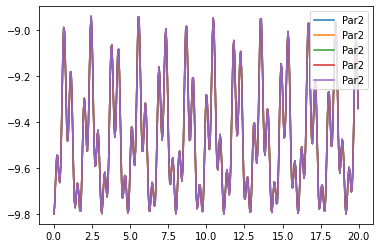

In [157]:
plotenergy(y,2)
#plotenergy(y71,7)
plotenergy(y3,3)
plotenergy(y4,4)
plotenergy(y5,5)
plotenergy(y7,7)

In [147]:
theta1,omega1, theta2,omega2 = y21.y[0],y21.y[1],y21.y[2],y21.y[3]


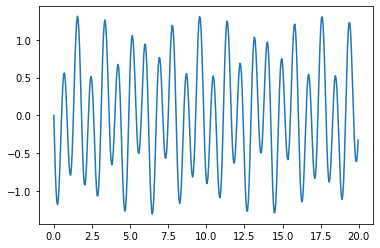

In [149]:
plt.plot(y71.t, omega1)